In [1]:
import numpy as np
import cv2
import requests
from io import BytesIO

import matplotlib.pyplot as plt
from PIL import Image

## 2. Carregar as três imagens

- **Imagem 1 — escura demais**
- **Imagem 2 — clara demais / saturada**
- **Imagem 3 — bem exposta**

In [ ]:
# Endereço da pasta com as imagens no GitHub
url_base = (
    "https://raw.githubusercontent.com/"
    "lianeheidemann/atividades-processamento-de-imagens/"
    "main/atividade/atividade-2/input/"
)

def carregar_imagem(nome_arquivo):
    resposta = requests.get(url_base + nome_arquivo)
    resposta.raise_for_status()
    return Image.open(BytesIO(resposta.content))

# Imagem 1: escura demais / Imagem 2: clara demais ou saturada / Imagem 3: bem exposta
imagem_1 = carregar_imagem("input_1.png")
imagem_2 = carregar_imagem("input_2.png")
imagem_3 = carregar_imagem("input_3.png")

imagem_cinza_1 = np.array(imagem_1.convert("L"), dtype=np.uint8)
imagem_cinza_2 = np.array(imagem_2.convert("L"), dtype=np.uint8)
imagem_cinza_3 = np.array(imagem_3.convert("L"), dtype=np.uint8)

fig, eixos = plt.subplots(1, 3, figsize=(15, 5))
titulos = ["Imagem 1 — escura demais", "Imagem 2 — clara/saturada", "Imagem 3 — bem exposta"]
for eixo, imagem, titulo in zip(eixos, [imagem_cinza_1, imagem_cinza_2, imagem_cinza_3], titulos):
    eixo.imshow(imagem, cmap="gray", vmin=0, vmax=255)
    eixo.set_title(titulo)
    eixo.axis("off")
plt.tight_layout()
plt.show()

### 1.1 Histograma

In [ ]:
def histograma_pixel_a_pixel(imagem):
    histograma = np.zeros(256, dtype=int)

    for px in imagem.ravel():
        histograma[px] += 1

    plt.figure(figsize=(14, 4))
    plt.bar(range(256), histograma)
    plt.xlabel("Nível de cinza")
    plt.ylabel("Quantidade de pixels")
    plt.title("Histograma pixel a pixel")
    plt.show()


def histograma_matplotlib(imagem, titulo="Histograma da imagem"):
    plt.figure(figsize=(14, 4))
    plt.hist(imagem.ravel(), bins=256, range=(0, 256), color="gray")
    plt.xlabel("Nível de cinza")
    plt.ylabel("Quantidade de pixels")
    plt.title(titulo)
    plt.show()


matriz_1 = np.array(imagem_cinza_1)

histograma_pixel_a_pixel(matriz_1)
histograma_matplotlib(matriz_1, "Histograma com Matplotlib")

### 1.2 Limiarização

In [4]:
def limiarizacao_pixel_a_pixel(imagem, limiar, tipo="superior"):
    """
    Aplica limiarização binária percorrendo a imagem pixel a pixel.

    tipo="superior":
        pixels >= limiar recebem 255
        pixels < limiar recebem 0

    tipo="inferior":
        pixels <= limiar recebem 255
        pixels > limiar recebem 0
    """
    resultado = np.zeros_like(imagem)

    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):

            if tipo == "superior":
                if imagem[i, j] >= limiar:
                    resultado[i, j] = 255

            elif tipo == "inferior":
                if imagem[i, j] <= limiar:
                    resultado[i, j] = 255

    return resultado


def limiarizacao_numpy(imagem, limiar, tipo="superior"):
    """
    Aplica limiarização binária usando operações vetorizadas do NumPy.
    """
    if tipo == "superior":
        return np.where(imagem >= limiar, 255, 0).astype(np.uint8)

    elif tipo == "inferior":
        return np.where(imagem <= limiar, 255, 0).astype(np.uint8)

    else:
        raise ValueError("O tipo deve ser 'superior' ou 'inferior'.")

In [ ]:
matriz_1 = np.array(imagem_cinza_1)
limiar = 128

resultado_pixel = limiarizacao_pixel_a_pixel(matriz_1, limiar)
resultado_numpy = limiarizacao_numpy(matriz_1, limiar)

fig, eixos = plt.subplots(1, 3, figsize=(15, 5))

eixos[0].imshow(matriz_1, cmap="gray")
eixos[0].set_title("Original")

eixos[1].imshow(resultado_pixel, cmap="gray")
eixos[1].set_title("Pixel a pixel")

eixos[2].imshow(resultado_numpy, cmap="gray")
eixos[2].set_title("NumPy")

for eixo in eixos:
    eixo.axis("off")

plt.tight_layout()
plt.show()

### 1.3 Expansão de contraste

In [6]:
def expansao_contraste_pixel_a_pixel(imagem):
    L = imagem.min()
    H = imagem.max()

    if H == L:
        return imagem.copy()

    resultado = np.zeros_like(imagem)

    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):
            resultado[i, j] = (
                (float(imagem[i, j]) - float(L))
                * 255
                / (float(H) - float(L))
            )

    return resultado.astype(np.uint8)


def expansao_contraste_numpy(imagem):
    """
    Aplica expansão de contraste usando operações vetorizadas do NumPy.
    """
    L = imagem.min()
    H = imagem.max()

    if H == L:
        return imagem.copy()

    resultado = (imagem.astype(float) - L) * 255 / (H - L)

    return resultado.astype(np.uint8)

In [ ]:
matriz_3 = np.array(imagem_cinza_3)

resultado_pixel = expansao_contraste_pixel_a_pixel(matriz_3)
resultado_numpy = expansao_contraste_numpy(matriz_3)

fig, eixos = plt.subplots(1, 3, figsize=(15, 5))

eixos[0].imshow(matriz_3, cmap="gray", vmin=0, vmax=255)
eixos[0].set_title("Original")

eixos[1].imshow(resultado_pixel, cmap="gray", vmin=0, vmax=255)
eixos[1].set_title("Pixel a pixel")

eixos[2].imshow(resultado_numpy, cmap="gray", vmin=0, vmax=255)
eixos[2].set_title("NumPy")

for eixo in eixos:
    eixo.axis("off")

plt.tight_layout()
plt.show()

### 1.4 Equalização de histograma

In [8]:
def equalizacao_histograma_manual(imagem):
    """
    Equaliza o histograma manualmente.

    Espera uma imagem em tons de cinza (uint8).
    """
    histograma = np.zeros(256, dtype=int)

    # Calcula o histograma
    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):
            nivel = imagem[i, j]
            histograma[nivel] += 1

    # Calcula a distribuição acumulada (CDF)
    cdf = np.cumsum(histograma)

    # Normaliza a CDF para o intervalo [0, 255]
    cdf_normalizada = 255 * cdf / cdf[-1]

    resultado = np.zeros_like(imagem)

    # Substitui cada pixel pelo novo nível de cinza
    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):
            resultado[i, j] = cdf_normalizada[imagem[i, j]]

    return resultado.astype(np.uint8)


def equalizacao_histograma_opencv(imagem):
    """
    Equaliza o histograma usando a função pronta do OpenCV.
    """
    return cv2.equalizeHist(imagem)

In [ ]:
matriz_3 = np.array(imagem_cinza_3)

resultado_manual = equalizacao_histograma_manual(matriz_3)
resultado_opencv = equalizacao_histograma_opencv(matriz_3)

fig, eixos = plt.subplots(1, 3, figsize=(15, 5))

eixos[0].imshow(matriz_3, cmap="gray", vmin=0, vmax=255)
eixos[0].set_title("Original")

eixos[1].imshow(resultado_manual, cmap="gray", vmin=0, vmax=255)
eixos[1].set_title("Equalização manual")

eixos[2].imshow(resultado_opencv, cmap="gray", vmin=0, vmax=255)
eixos[2].set_title("Equalização OpenCV")

for eixo in eixos:
    eixo.axis("off")

plt.tight_layout()
plt.show()

### 1.5 Correção gamma

In [10]:
def correcao_gamma_pixel_a_pixel(imagem, gamma):
    """
    Aplica correção de gamma percorrendo a imagem pixel a pixel.

    gamma < 1  -> clareia a imagem
    gamma > 1  -> escurece a imagem
    gamma = 1  -> mantém a imagem
    """
    if gamma <= 0:
        raise ValueError("O valor de gamma deve ser maior que zero.")

    resultado = np.zeros_like(imagem)

    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):
            r = imagem[i, j] / 255.0
            resultado[i, j] = 255 * (r ** gamma)

    return resultado.astype(np.uint8)


def correcao_gamma_numpy(imagem, gamma):
    """
    Aplica correção de gamma usando operações vetorizadas do NumPy.
    """
    if gamma <= 0:
        raise ValueError("O valor de gamma deve ser maior que zero.")

    imagem_normalizada = imagem / 255.0
    resultado = 255 * (imagem_normalizada ** gamma)

    return resultado.astype(np.uint8)

In [ ]:
matriz_1 = np.array(imagem_cinza_1)
gamma = 0.5

resultado_pixel = correcao_gamma_pixel_a_pixel(matriz_1, gamma)
resultado_numpy = correcao_gamma_numpy(matriz_1, gamma)

fig, eixos = plt.subplots(1, 3, figsize=(15, 5))

eixos[0].imshow(matriz_1, cmap="gray", vmin=0, vmax=255)
eixos[0].set_title("Original")

eixos[1].imshow(resultado_pixel, cmap="gray", vmin=0, vmax=255)
eixos[1].set_title("Gamma — pixel a pixel")

eixos[2].imshow(resultado_numpy, cmap="gray", vmin=0, vmax=255)
eixos[2].set_title("Gamma — NumPy")

for eixo in eixos:
    eixo.axis("off")

plt.tight_layout()
plt.show()

## 3. Imagem 1 — escura demais

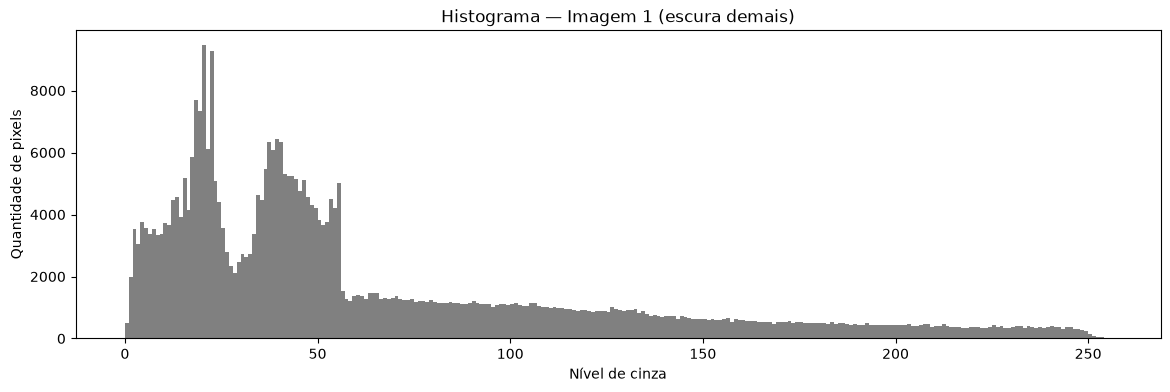

In [12]:
histograma_matplotlib(imagem_cinza_1, "Histograma — Imagem 1 (escura demais)")

**Diagnóstico:** as intensidades estão fortemente concentradas entre 0 e 60
(93,5% dos pixels), com média 13,7 e valor máximo de apenas 108 — a imagem não usa
boa parte da faixa de 0 a 255. Isso indica uma imagem muito escura, na qual quase
não há pixels claros.

**Operação escolhida:** expansão de contraste, com **L = 0** e **H = 108**. Como a
imagem está toda concentrada abaixo de 108 (não usa a faixa superior de intensidades),
há espaço real para esticar o intervalo ocupado até cobrir toda a faixa de 0 a 255,
o que aumenta o contraste sem distorcer a distribuição relativa dos tons.

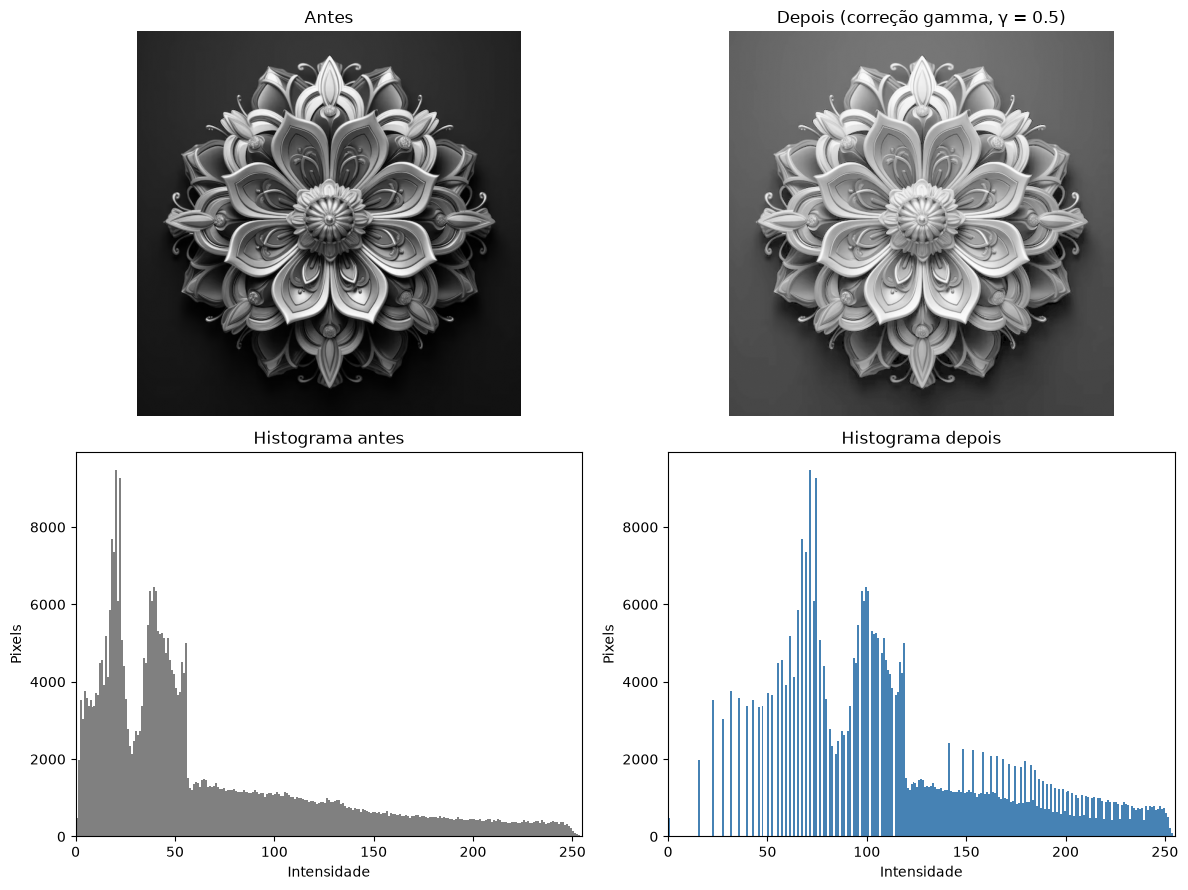

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Converte a imagem em uma matriz NumPy
matriz_1 = np.array(imagem_cinza_1)

# Aplica a expansão de contraste
resultado_1 = expansao_contraste_numpy(imagem_cinza_1)

fig, eixos = plt.subplots(2, 2, figsize=(12, 9))

# Imagens
eixos[0, 0].imshow(matriz_1, cmap="gray", vmin=0, vmax=255)
eixos[0, 0].set_title("Antes")
eixos[0, 0].axis("off")

eixos[0, 1].imshow(resultado_1, cmap="gray", vmin=0, vmax=255)
eixos[0, 1].set_title("Depois (expansão de contraste, L=0, H=108)")
eixos[0, 1].axis("off")

# Histogramas
eixos[1, 0].hist(
    matriz_1.ravel(),
    bins=256,
    range=(0, 256),
    color="gray"
)
eixos[1, 0].set_title("Histograma antes")
eixos[1, 0].set_xlabel("Intensidade")
eixos[1, 0].set_ylabel("Pixels")
eixos[1, 0].set_xlim(0, 255)

eixos[1, 1].hist(
    resultado_1.ravel(),
    bins=256,
    range=(0, 256),
    color="steelblue"
)
eixos[1, 1].set_title("Histograma depois")
eixos[1, 1].set_xlabel("Intensidade")
eixos[1, 1].set_ylabel("Pixels")
eixos[1, 1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

## 4. Imagem 2 — clara demais / saturada

<Figure size 1400x400 with 0 Axes>

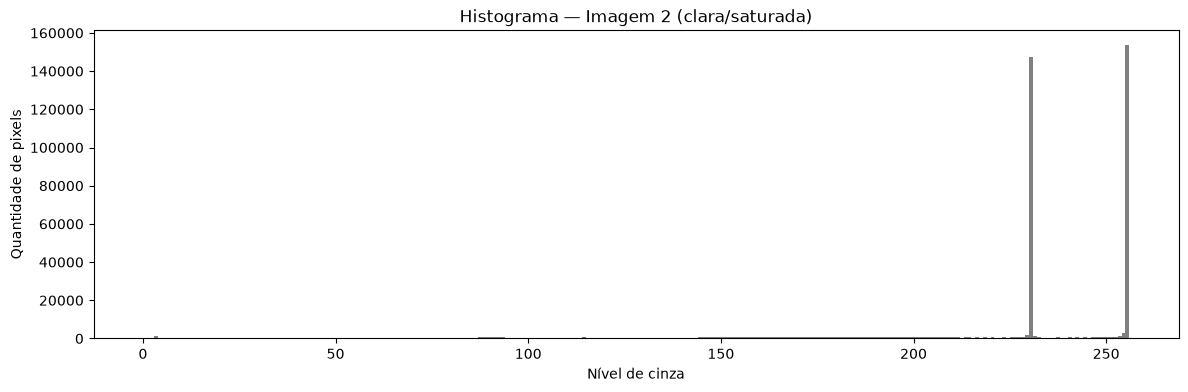

In [14]:
plt.figure(figsize=(14, 4))
histograma_matplotlib(imagem_cinza_2, "Histograma — Imagem 2 (clara/saturada)")

**Diagnóstico:** as intensidades se concentram fortemente perto do branco — 81,5%
dos pixels estão acima de 200. Média 229,3 e valor mínimo de 79, ou seja, quase
nenhum pixel na parte escura da faixa. É uma imagem clara demais/saturada, com o céu
ao fundo estourado (muitos pixels em 255).

**Operação escolhida:** correção gamma, com **γ = 4**. Como o valor máximo da imagem
já é 255, a expansão de contraste não teria efeito sobre a saturação (o teto já está
no limite); a equalização de histograma tende a distorcer fortemente uma distribuição
já tão deslocada para o branco. A correção gamma com γ > 1 escurece a imagem de forma
suave e proporcional, reduzindo a saturação sem gerar esses artefatos.

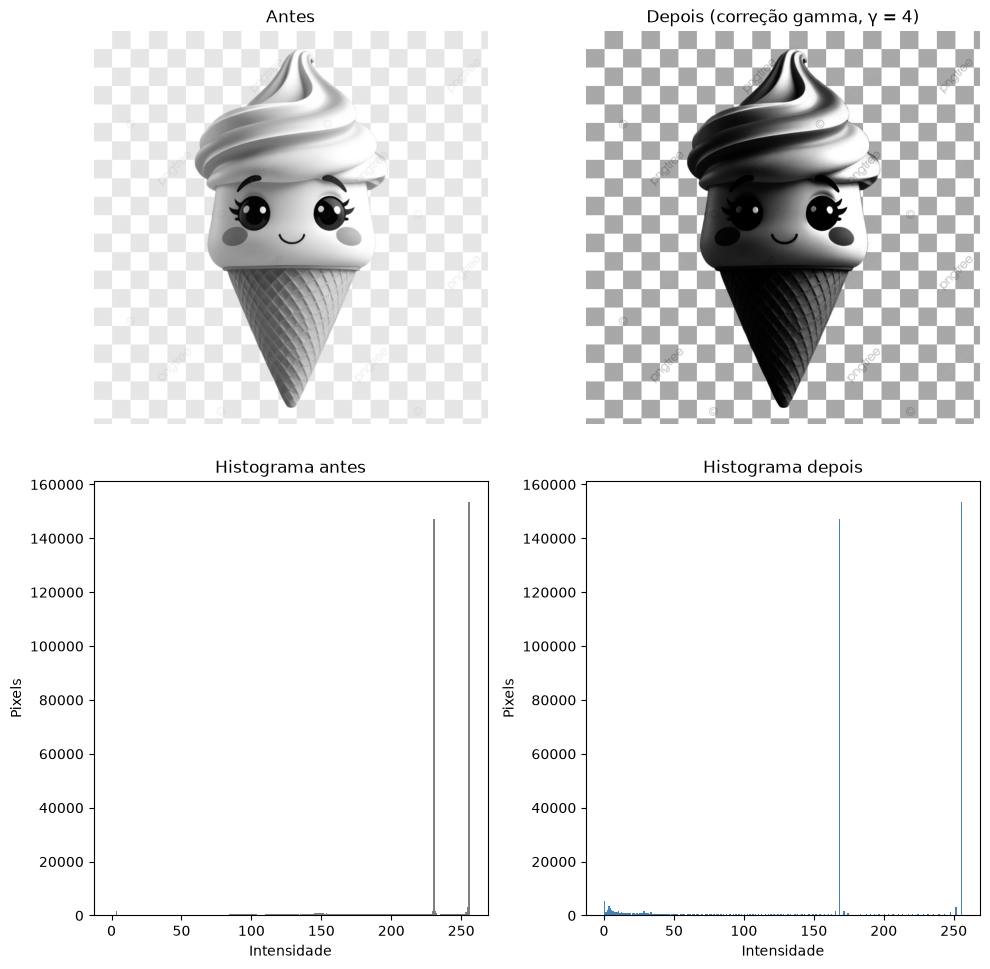

In [15]:
matriz_2 = np.array(imagem_cinza_2)

gamma_2 = 4
resultado_2 = correcao_gamma_numpy(imagem_cinza_2, gamma_2)

fig, eixos = plt.subplots(2, 2, figsize=(10, 10))

eixos[0, 0].imshow(matriz_2, cmap="gray", vmin=0, vmax=255)
eixos[0, 0].set_title("Antes")
eixos[0, 0].axis("off")

eixos[0, 1].imshow(resultado_2, cmap="gray", vmin=0, vmax=255)
eixos[0, 1].set_title(f"Depois (correção gamma, γ = {gamma_2})")
eixos[0, 1].axis("off")

eixos[1, 0].hist(matriz_2.ravel(), bins=256, range=(0, 256), color="gray")
eixos[1, 0].set_title("Histograma antes")
eixos[1, 0].set_xlabel("Intensidade")
eixos[1, 0].set_ylabel("Pixels")

eixos[1, 1].hist(resultado_2.ravel(), bins=256, range=(0, 256), color="steelblue")
eixos[1, 1].set_title("Histograma depois")
eixos[1, 1].set_xlabel("Intensidade")
eixos[1, 1].set_ylabel("Pixels")

plt.tight_layout()
plt.show()

## 5. Imagem 3 — bem exposta

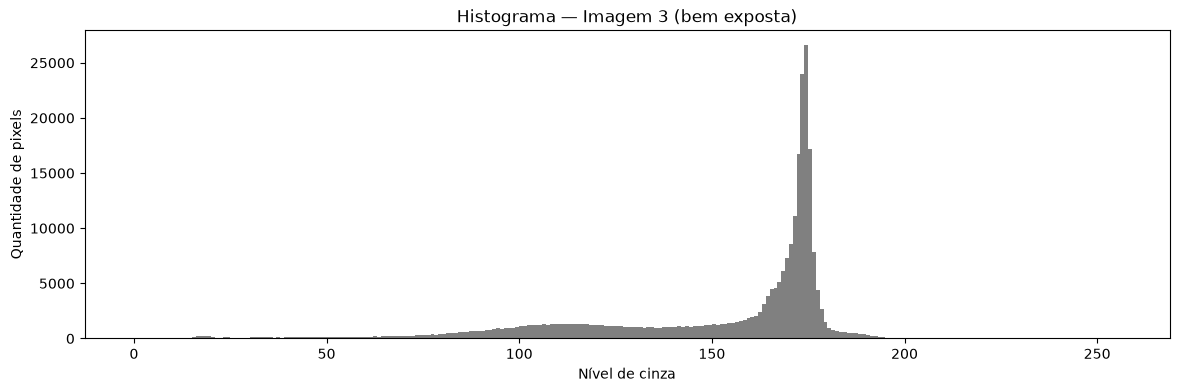

In [16]:
histograma_matplotlib(imagem_cinza_3, "Histograma — Imagem 3 (bem exposta)")

**Diagnóstico:** as intensidades estão amplamente distribuídas entre 7 e 255 (média
113,4, desvio 53,9), sem grandes acúmulos nas extremidades — um histograma largo e
relativamente bem espalhado, típico de uma imagem de tons médios já bem exposta.

**Operação escolhida:** equalização de histograma. Como a imagem já ocupa quase toda
a faixa de intensidades (mínimo 7, máximo 255), a expansão de contraste teria pouco
efeito; a equalização redistribui as intensidades de acordo com a distribuição
acumulada, melhorando o contraste local sem depender de um intervalo estreito para
esticar.

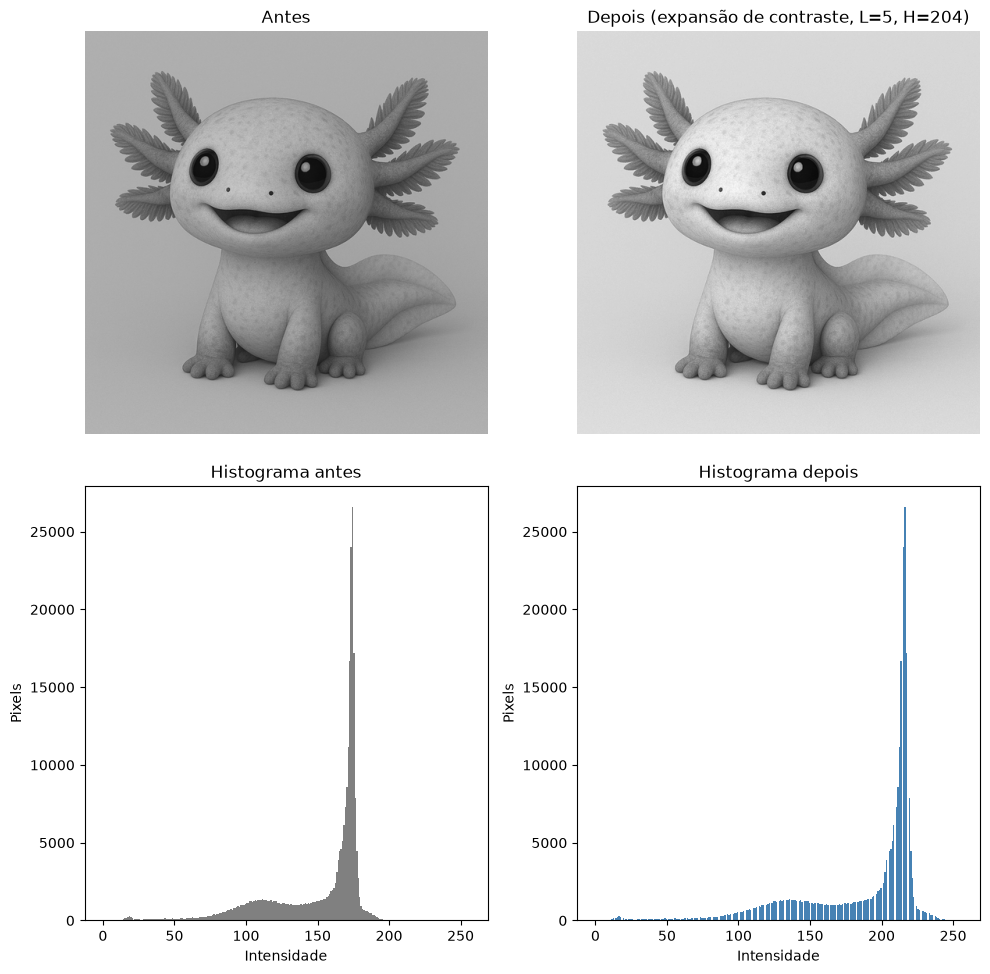

In [17]:
matriz_3 = np.array(imagem_cinza_3)

resultado_3 = equalizacao_histograma_manual(imagem_cinza_3)

fig, eixos = plt.subplots(2, 2, figsize=(10, 10))

eixos[0, 0].imshow(matriz_3, cmap="gray", vmin=0, vmax=255)
eixos[0, 0].set_title("Antes")
eixos[0, 0].axis("off")

eixos[0, 1].imshow(resultado_3, cmap="gray", vmin=0, vmax=255)
eixos[0, 1].set_title("Depois (equalização de histograma)")
eixos[0, 1].axis("off")

eixos[1, 0].hist(matriz_3.ravel(), bins=256, range=(0, 256), color="gray")
eixos[1, 0].set_title("Histograma antes")
eixos[1, 0].set_xlabel("Intensidade")
eixos[1, 0].set_ylabel("Pixels")

eixos[1, 1].hist(resultado_3.ravel(), bins=256, range=(0, 256), color="steelblue")
eixos[1, 1].set_title("Histograma depois")
eixos[1, 1].set_xlabel("Intensidade")
eixos[1, 1].set_ylabel("Pixels")

plt.tight_layout()
plt.show()

## 6. Conclusão

A operação que fez **menos diferença** foi a aplicada na **Imagem 1 (escura demais)**: a
diferença média de intensidade entre antes e depois foi de apenas 18,2 níveis, contra
22,9 na Imagem 3 e 45,1 na Imagem 2. Isso acontece porque, apesar de a Imagem 1 ser
muito escura, a maior parte de seus pixels está concentrada bem perto de zero (média
13,7); mesmo esticando o intervalo realmente ocupado pela imagem (L=0, H=108) para toda
a faixa de 0 a 255, o deslocamento absoluto médio de cada pixel continua pequeno. Já a
Imagem 2 tinha o problema de exposição mais grave (forte saturação perto do branco), e
a correção gamma aplicada para reduzi-la produziu a mudança mais visível das três.